In [253]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

df=pd.read_csv('D:\Data Mining & Visualisasi\zomato.csv')
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [168]:
df.shape

(51717, 17)

In [169]:
df.info() ## sudah mengandung dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

There are some unnecessary columns like url, address, phone number and location (As we already have location in listed_in(city) column.
Menu_item is also not of use for us as it is empty for all the rows.
Since approx cost for 2 people column name is very big, we can rename the same.
Reviews list is not of use for us as we already have average rating in a separate column.

In [170]:
df.drop(columns=['url','address','phone','reviews_list','menu_item'],inplace=True)
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet,Banashankari
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet,Banashankari


In [171]:
df.rename(columns={
    'listed_in(city)':'city_loc',
    'approx_cost(for two people)':'costfor2',
    'listed_in(type)':'type'},
    inplace=True)
df

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,costfor2,type,city_loc
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet,Banashankari
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...
51712,Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,Whitefield,Bar,NaN,Continental,"1,500",Pubs and bars,Whitefield
51713,Vinod Bar And Restaurant,No,No,NaN,0,Whitefield,Bar,NaN,Finger Food,600,Pubs and bars,Whitefield
51714,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,Whitefield,Bar,NaN,Finger Food,"2,000",Pubs and bars,Whitefield
51715,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,"2,500",Pubs and bars,Whitefield


In [172]:
sum(df.duplicated())

108

In [173]:
df=df.drop_duplicates()

In [174]:
sum(df.duplicated())

0

In [175]:
df.shape

(51609, 12)

In [176]:
df.drop(columns=['location'],inplace=True)

C:\Users\cikar\AppData\Local\Temp\ipykernel_14096\1347744693.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['location'],inplace=True)


In [177]:
df.shape

(51609, 11)

In [178]:
df.rename(columns={'city_loc':'location'},inplace=True)
df

C:\Users\cikar\AppData\Local\Temp\ipykernel_14096\4056887228.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'city_loc':'location'},inplace=True)


,name,online_order,book_table,rate,votes,rest_type,dish_liked,cuisines,costfor2,type,location
0,Jalsa,Yes,Yes,4.1/5,775,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8/5,918,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet,Banashankari
4,Grand Village,No,No,3.8/5,166,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...
51712,Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,Bar,NaN,Continental,"1,500",Pubs and bars,Whitefield
51713,Vinod Bar And Restaurant,No,No,NaN,0,Bar,NaN,Finger Food,600,Pubs and bars,Whitefield
51714,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,Bar,NaN,Finger Food,"2,000",Pubs and bars,Whitefield
51715,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,Bar,"Cocktails, Pizza, Buttermilk",Finger Food,"2,500",Pubs and bars,Whitefield


In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51609 entries, 0 to 51716
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   name          51609 non-null  object
 1   online_order  51609 non-null  object
 2   book_table    51609 non-null  object
 3   rate          43854 non-null  object
 4   votes         51609 non-null  int64 
 5   rest_type     51382 non-null  object
 6   dish_liked    23595 non-null  object
 7   cuisines      51564 non-null  object
 8   costfor2      51265 non-null  object
 9   type          51609 non-null  object
 10  location      51609 non-null  object
dtypes: int64(1), object(10)
memory usage: 4.7+ MB


In [180]:
df.describe(include='all')

,name,online_order,book_table,rate,votes,rest_type,dish_liked,cuisines,costfor2,type,location
count,51609,51609,51609,43854,51609.000000,51382,23595,51564,51265,51609,51609
unique,8792,2,2,64,NaN,93,5271,2723,70,7,30
top,Cafe Coffee Day,Yes,No,NEW,NaN,Quick Bites,Biryani,North Indian,300,Delivery,BTM
freq,96,30361,45193,2195,NaN,19096,182,2907,7558,25867,3266
mean,NaN,NaN,NaN,NaN,283.283361,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,803.282771,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,41.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,198.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [181]:
print(df.isnull().sum())

name                0
online_order        0
book_table          0
rate             7755
votes               0
rest_type         227
dish_liked      28014
cuisines           45
costfor2          344
type                0
location            0
dtype: int64


In [182]:
(df.isna().sum()/len(df))*100

name             0.000000
online_order     0.000000
book_table       0.000000
rate            15.026449
votes            0.000000
rest_type        0.439846
dish_liked      54.281230
cuisines         0.087194
costfor2         0.666550
type             0.000000
location         0.000000
dtype: float64

There are more than 50% missing values.
The data is a long string with mutiple dishes which doesn't give proper idea.
Since there is huge number of missing values imputing with mode will create a huge bias.
The best option to handle this is to remove this column.

In [183]:
df['dish_liked'].value_counts()

dish_liked
Biryani                                                                                              182
Chicken Biryani                                                                                       73
Friendly Staff                                                                                        69
Waffles                                                                                               68
Paratha                                                                                               57
                                                                                                    ... 
Banana Cake, Ginger Lemon Tea, Poha, Mango Shake, Masala Chai, Paneer Sandwich, Vada Pav               1
Butter Chicken, Shawarma Roll, Chicken Shawarama, Chicken Grill, Rolls, Al Faham Chicken, Biryani      1
Filter Coffee, Sandwich, Bonda, Vada, Masala Dosa, Salad, Aloo Curry                                   1
Burgers, Fries, Jumbo Royale Burger, Salads,

In [184]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51609 entries, 0 to 51716
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   name          51609 non-null  object
 1   online_order  51609 non-null  object
 2   book_table    51609 non-null  object
 3   rate          43854 non-null  object
 4   votes         51609 non-null  int64 
 5   rest_type     51382 non-null  object
 6   dish_liked    23595 non-null  object
 7   cuisines      51564 non-null  object
 8   costfor2      51265 non-null  object
 9   type          51609 non-null  object
 10  location      51609 non-null  object
dtypes: int64(1), object(10)
memory usage: 4.7+ MB


In [185]:
df.drop(columns=['dish_liked'],inplace=True)
df

C:\Users\cikar\AppData\Local\Temp\ipykernel_14096\1314048110.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['dish_liked'],inplace=True)


,name,online_order,book_table,rate,votes,rest_type,cuisines,costfor2,type,location
0,Jalsa,Yes,Yes,4.1/5,775,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8/5,918,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,Grand Village,No,No,3.8/5,166,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...
51712,Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,Bar,Continental,"1,500",Pubs and bars,Whitefield
51713,Vinod Bar And Restaurant,No,No,NaN,0,Bar,Finger Food,600,Pubs and bars,Whitefield
51714,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,Bar,Finger Food,"2,000",Pubs and bars,Whitefield
51715,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,Bar,Finger Food,"2,500",Pubs and bars,Whitefield


In [186]:
(df.isna().sum()/len(df))*100

name             0.000000
online_order     0.000000
book_table       0.000000
rate            15.026449
votes            0.000000
rest_type        0.439846
cuisines         0.087194
costfor2         0.666550
type             0.000000
location         0.000000
dtype: float64

In [187]:
df['rate'].value_counts()

rate
NEW       2195
3.9/5     2095
3.8/5     2020
3.7/5     2009
3.9 /5    1872
          ... 
2.2 /5       7
2.0 /5       7
2.0/5        4
1.8 /5       3
1.8/5        2
Name: count, Length: 64, dtype: int64

Issues with rate column

All the values are in string format rather than float.
There are non numerical values like 'NEW' and '-'.

In [188]:
def cleaning_rate(value):
    if(value=='NEW' or value=='-'):
        return np.nan
    else:
        return float(str(value).split('/')[0])
    
df['rate']=df['rate'].apply(cleaning_rate)

C:\Users\cikar\AppData\Local\Temp\ipykernel_14096\750912959.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rate']=df['rate'].apply(cleaning_rate)


In [189]:
df['rate'].value_counts()

rate
3.9    3967
3.8    3870
3.7    3814
3.6    3311
4.0    3180
4.1    2942
3.5    2781
3.4    2472
3.3    2305
4.2    2179
3.2    1867
4.3    1686
3.1    1561
4.4    1137
3.0    1022
2.9     801
4.5     653
2.8     600
2.7     307
4.6     299
2.6     260
4.7     167
2.5     101
2.4      70
4.8      66
4.9      55
2.3      51
2.2      26
2.1      24
2.0      11
1.8       5
Name: count, dtype: int64

In [190]:
print(df.isnull().sum())

name                0
online_order        0
book_table          0
rate            10019
votes               0
rest_type         227
cuisines           45
costfor2          344
type                0
location            0
dtype: int64


<Axes: ylabel='rate'>

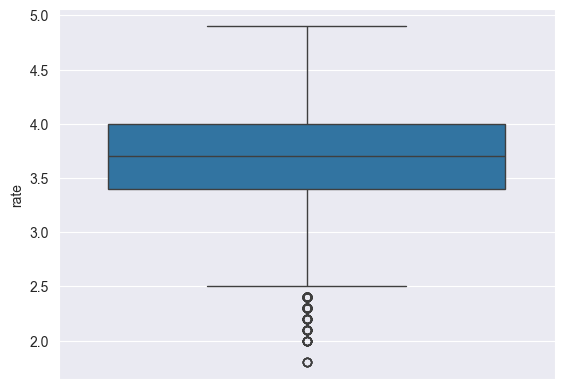

In [191]:
sns.set_style("darkgrid")
sns.boxplot(df['rate'])

In [192]:
# There is a presence of outliers in the data so it's a good idea to impute median in place of nan
df['rate']=df['rate'].fillna(df['rate'].median())
df['rate'].isna().sum()

C:\Users\cikar\AppData\Local\Temp\ipykernel_14096\2281000533.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rate']=df['rate'].fillna(df['rate'].median())


0


Imputing the median instead of the mean is often preferred in the presence of outliers for several reasons:

Robustness to Outliers: The median is less affected by extreme values compared to the mean. If your data contains outliers, they can significantly skew the mean, leading to a less accurate representation of the central tendency of the data.

True Central Value: The median represents the middle value of a sorted dataset, which means that it gives a better indication of where most of the data points are located when outliers are present.

Better Performance: When analyzing data distributions, using the median can lead to better performance in models that are sensitive to outliers, such as linear regression.

In summary, if your data contains outliers, imputing with the median helps maintain a more representative measure of central tendency, which can improve the overall quality of your data analysis or modeling efforts.

In [193]:
print(df.isnull().sum())

name              0
online_order      0
book_table        0
rate              0
votes             0
rest_type       227
cuisines         45
costfor2        344
type              0
location          0
dtype: int64


In [194]:
df['rest_type'].value_counts()

rest_type
Quick Bites                   19096
Casual Dining                 10309
Cafe                           3727
Delivery                       2600
Dessert Parlor                 2260
                              ...  
Dessert Parlor, Kiosk             2
Food Court, Beverage Shop         2
Dessert Parlor, Food Court        2
Sweet Shop, Dessert Parlor        1
Quick Bites, Kiosk                1
Name: count, Length: 93, dtype: int64

In [195]:
# Menghitung jumlah kemunculan setiap jenis restoran
top_rest_types = df['rest_type'].value_counts().head(10)
print(top_rest_types)

rest_type
Quick Bites           19096
Casual Dining         10309
Cafe                   3727
Delivery               2600
Dessert Parlor         2260
Takeaway, Delivery     2031
Casual Dining, Bar     1148
Bakery                 1140
Beverage Shop           865
Bar                     697
Name: count, dtype: int64


Di atas adalah TOP 10 jenis resto yang ada. Sehingga diambil keputusan, untuk resto dengan nilai 'count' di bawah 500 akan dikategorikan sebagai 'others'

Observations

There are too many categories of rest type
Data is not clean has many values which are comma separated.
Best thing to clean this will be to combine rest_types which are less frequent to other category

In [236]:
df['rest_type'].value_counts()
newrest_type=pd.DataFrame(df['rest_type'].value_counts())
newrest_type[newrest_type['count']<1000]
newrest_type=newrest_type[newrest_type['count']<1000]
newrest_type

,count
rest_type,
Beverage Shop,865
Food Court,621


In [237]:
def combine_restt(value):
    if (value in newrest_type.index):
        return 'Others'
    else:
        return value
df['rest_type']=df['rest_type'].apply(combine_restt)
df['rest_type']

C:\Users\cikar\AppData\Local\Temp\ipykernel_14096\694883163.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rest_type']=df['rest_type'].apply(combine_restt)


0        Casual Dining
1        Casual Dining
2               Others
3          Quick Bites
4        Casual Dining
             ...      
51712              Bar
51713              Bar
51714              Bar
51715              Bar
51716           Others
Name: rest_type, Length: 51382, dtype: object

In [198]:
print(df.isnull().sum())

name              0
online_order      0
book_table        0
rate              0
votes             0
rest_type       227
cuisines         45
costfor2        344
type              0
location          0
dtype: int64


Observations for costfor2

There are null values in the column.
The datatype is object.
We cannot directly astype the column into int because of the presence of commas in the values.

In [199]:
# Removing commas from the values
df['costfor2'].str.replace(",","")
df['costfor2']=df['costfor2'].str.replace(",","")

C:\Users\cikar\AppData\Local\Temp\ipykernel_14096\1101765639.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['costfor2']=df['costfor2'].str.replace(",","")


In [200]:
df

,name,online_order,book_table,rate,votes,rest_type,cuisines,costfor2,type,location
0,Jalsa,Yes,Yes,4.1,775,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,Others,"Cafe, Mexican, Italian",800,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,Grand Village,No,No,3.8,166,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...
51712,Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6,27,Bar,Continental,1500,Pubs and bars,Whitefield
51713,Vinod Bar And Restaurant,No,No,3.7,0,Bar,Finger Food,600,Pubs and bars,Whitefield
51714,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,3.7,0,Bar,Finger Food,2000,Pubs and bars,Whitefield
51715,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3,236,Bar,Finger Food,2500,Pubs and bars,Whitefield


In [201]:
# Convert 'costfor2' to numeric
df['costfor2']=pd.to_numeric(df['costfor2'],errors='coerce')

C:\Users\cikar\AppData\Local\Temp\ipykernel_14096\4234354680.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['costfor2']=pd.to_numeric(df['costfor2'],errors='coerce')


In [202]:
print(df.isnull().sum())

name              0
online_order      0
book_table        0
rate              0
votes             0
rest_type       227
cuisines         45
costfor2        344
type              0
location          0
dtype: int64


In [203]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51609 entries, 0 to 51716
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          51609 non-null  object 
 1   online_order  51609 non-null  object 
 2   book_table    51609 non-null  object 
 3   rate          51609 non-null  float64
 4   votes         51609 non-null  int64  
 5   rest_type     51382 non-null  object 
 6   cuisines      51564 non-null  object 
 7   costfor2      51265 non-null  float64
 8   type          51609 non-null  object 
 9   location      51609 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 4.3+ MB


In [204]:
df.describe()

,rate,votes,costfor2
count,51609.000000,51609.000000,51265.000000
mean,3.700114,283.283361,555.170682
std,0.395393,803.282771,438.587661
min,1.800000,0.000000,40.000000
25%,3.500000,7.000000,300.000000
50%,3.700000,41.000000,400.000000
75%,3.900000,198.000000,650.000000
max,4.900000,16832.000000,6000.000000


In [205]:
df['costfor2'].isna().sum()


344

In [206]:
# Mengambil baris yang memiliki nilai hilang dalam kolom 'costfor2'
missing_costfor2 = df[df['costfor2'].isna()]
missing_costfor2

,name,online_order,book_table,rate,votes,rest_type,cuisines,costfor2,type,location
1662,Papa Khan Rasoi,No,No,3.7,0,NaN,NaN,NaN,Delivery,Bannerghatta Road
1768,Innate,No,No,3.7,0,Delivery,Beverages,NaN,Delivery,Bannerghatta Road
1795,Super Chef's (New Royal treat),No,No,3.7,0,Quick Bites,"North Indian, Chinese, South Indian",NaN,Delivery,Bannerghatta Road
3069,Super Chef's (New Royal treat),No,No,3.7,0,Quick Bites,"North Indian, Chinese, South Indian",NaN,Delivery,Basavanagudi
3774,The Hub - Ibis Bengaluru,No,No,3.9,237,Bar,Finger Food,NaN,Buffet,Bellandur
...,...,...,...,...,...,...,...,...,...,...
50940,Cinnabon,No,No,4.0,80,Quick Bites,"Beverages, American, Bakery",NaN,Desserts,Whitefield
51233,Mayas kitchen,No,No,3.7,0,Casual Dining,"South Indian, Chinese, Chettinad",NaN,Dine-out,Whitefield
51247,Mast Kalandar,No,No,2.6,76,Casual Dining,North Indian,NaN,Dine-out,Whitefield
51271,Karavalli Food Court,No,No,3.2,4,Casual Dining,South Indian,NaN,Dine-out,Whitefield


Cost for 2 people depends on various factor one important factor would be type of restuarant.
Let's first remove all the NAN values form rest_type
We then impute the costfor2 based on the restaurant type

In [207]:
print(df.isnull().sum())

name              0
online_order      0
book_table        0
rate              0
votes             0
rest_type       227
cuisines         45
costfor2        344
type              0
location          0
dtype: int64


In [208]:
df.dropna(subset=['rest_type'],inplace=True)

C:\Users\cikar\AppData\Local\Temp\ipykernel_14096\1797407566.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=['rest_type'],inplace=True)


In [209]:
print(df.isnull().sum())

name              0
online_order      0
book_table        0
rate              0
votes             0
rest_type         0
cuisines         24
costfor2        321
type              0
location          0
dtype: int64


In [210]:
# Nan values are replaced by median of that type of restaurant
df['costfor2'].isna().sum()

321

In [211]:
df['rest_type'].unique()

array(['Casual Dining', 'Others', 'Quick Bites', 'Cafe', 'Delivery',
       'Dessert Parlor', 'Bakery', 'Takeaway, Delivery', 'Beverage Shop',
       'Bar', 'Casual Dining, Bar', 'Food Court'], dtype=object)

In [212]:
def cleaning_resttype(value):
    if (value=='Takeaway, Delivery'):
        return 'Delivery'
    elif (value=='Casual Dining, Bar'):
        return 'Bar'
    else:
        return value
    
df['rest_type'].apply(cleaning_resttype).value_counts()
df['rest_type']=df['rest_type'].apply(cleaning_resttype)

C:\Users\cikar\AppData\Local\Temp\ipykernel_14096\1588983699.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rest_type']=df['rest_type'].apply(cleaning_resttype)


In [213]:
# Calculate the median costfor2 for each rest_type and round it to 0 decimal places
median_cost = round(df.groupby('rest_type')['costfor2'].median(), 0)
median_cost

rest_type
Bakery             400.0
Bar               1200.0
Beverage Shop      200.0
Cafe               600.0
Casual Dining      700.0
Delivery           400.0
Dessert Parlor     300.0
Food Court         400.0
Others             600.0
Quick Bites        300.0
Name: costfor2, dtype: float64

In [214]:
df['costfor2'].fillna(df['rest_type'].map(median_cost),inplace=True)

C:\Users\cikar\AppData\Local\Temp\ipykernel_14096\2726089572.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['costfor2'].fillna(df['rest_type'].map(median_cost),inplace=True)


In [215]:
df['costfor2'].isna().sum()

0

In [216]:
print(df.isnull().sum())

name             0
online_order     0
book_table       0
rate             0
votes            0
rest_type        0
cuisines        24
costfor2         0
type             0
location         0
dtype: int64


In [217]:
df['cuisines'].value_counts()

cuisines
North Indian                                       2893
North Indian, Chinese                              2357
South Indian                                       1826
Biryani                                             906
Bakery, Desserts                                    906
                                                   ... 
North Eastern, Street Food                            1
Continental, North Indian, Chinese, Pizza, Thai       1
Chinese, North Indian, Street Food, Rolls             1
BBQ, Arabian, Chinese, Kebab, Beverages               1
North Indian, Chinese, Arabian, Momos                 1
Name: count, Length: 2712, dtype: int64

In [218]:
def cleaning_cuisine(val):
    if (val=='North Indian, Chinese'):
        return 'Multicuisine'
    elif (val=='Bakery, Desserts'):
        return 'Desserts'
    elif (val=='Biryani'):
        return 'Multicuisine'
    elif ('Pizza' in str(val)):
        return 'Italian'
    elif (val=='North Indian'):
        return 'North Indian'
    elif (val=='South Indian'):
        return 'South Indian'
    else:
        return 'Others'
df['cuisines'].apply(cleaning_cuisine).value_counts()
df['cuisines']=df['cuisines'].apply(cleaning_cuisine)

C:\Users\cikar\AppData\Local\Temp\ipykernel_14096\3819412463.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cuisines']=df['cuisines'].apply(cleaning_cuisine)


In [219]:
print(df.isnull().sum())

name            0
online_order    0
book_table      0
rate            0
votes           0
rest_type       0
cuisines        0
costfor2        0
type            0
location        0
dtype: int64


In [220]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51382 entries, 0 to 51716
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          51382 non-null  object 
 1   online_order  51382 non-null  object 
 2   book_table    51382 non-null  object 
 3   rate          51382 non-null  float64
 4   votes         51382 non-null  int64  
 5   rest_type     51382 non-null  object 
 6   cuisines      51382 non-null  object 
 7   costfor2      51382 non-null  float64
 8   type          51382 non-null  object 
 9   location      51382 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 4.3+ MB


The data is cleaned up and ready for use now.

In [221]:
df.describe()

,rate,votes,costfor2
count,51382.000000,51382.000000,51382.000000
mean,3.701446,284.242303,555.666868
std,0.394906,804.886139,438.331974
min,1.800000,0.000000,40.000000
25%,3.500000,7.000000,300.000000
50%,3.700000,41.000000,400.000000
75%,3.900000,199.000000,700.000000
max,4.900000,16832.000000,6000.000000


In [222]:
df.describe(exclude='number')

,name,online_order,book_table,rest_type,cuisines,type,location
count,51382,51382,51382,51382,51382,51382,51382
unique,8758,2,2,10,6,7,30
top,Cafe Coffee Day,Yes,No,Quick Bites,Others,Delivery,BTM
freq,96,30244,44966,19096,40435,25740,3252


In [223]:
df

,name,online_order,book_table,rate,votes,rest_type,cuisines,costfor2,type,location
0,Jalsa,Yes,Yes,4.1,775,Casual Dining,Others,800.0,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,Casual Dining,Others,800.0,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,Others,Others,800.0,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,Quick Bites,Others,300.0,Buffet,Banashankari
4,Grand Village,No,No,3.8,166,Casual Dining,Others,600.0,Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...
51712,Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6,27,Bar,Others,1500.0,Pubs and bars,Whitefield
51713,Vinod Bar And Restaurant,No,No,3.7,0,Bar,Others,600.0,Pubs and bars,Whitefield
51714,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,3.7,0,Bar,Others,2000.0,Pubs and bars,Whitefield
51715,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3,236,Bar,Others,2500.0,Pubs and bars,Whitefield


## VISUALIZATION

In [224]:
demography_analysis = df.groupby('location')[['rate', 'votes']].mean().sort_values('rate', ascending=False)
print(demography_analysis)

                           rate       votes
location                                   
Church Street          3.786049  374.744420
MG Road                3.785857  399.132557
Brigade Road           3.784598  366.035674
Residency Road         3.767822  363.674505
Lavelle Road           3.763982  335.009781
Koramangala 6th Block  3.752698  374.387294
Koramangala 4th Block  3.749819  358.410701
Koramangala 5th Block  3.749344  367.936502
Koramangala 7th Block  3.748632  364.240082
Indiranagar            3.739686  422.094207
Old Airport Road       3.715983  408.981612
Malleshwaram           3.713449  240.010064
Frazer Town            3.712078  239.295608
BTM                    3.707257  300.383149
Basavanagudi           3.706166  222.613439
Jayanagar              3.696144  238.331356
Banashankari           3.671926  175.838747
HSR                    3.671148  216.839008
Rajajinagar            3.664804  184.587523
Kalyan Nagar           3.662269  136.117284
Kammanahalli           3.653916 

Correlation between average ratings and votes: 0.83


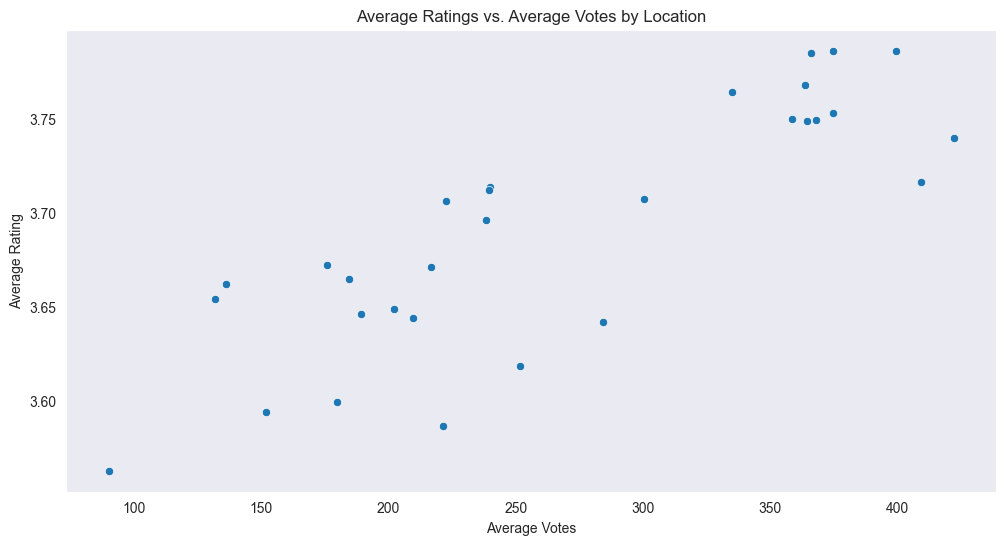

In [225]:
# Group by Location
location_analysis = df.groupby('location')[['rate', 'votes']].mean().reset_index()
location_analysis.sort_values('rate', ascending=False, inplace=True)

# Correlation Analysis
correlation = location_analysis['rate'].corr(location_analysis['votes'])
print(f'Correlation between average ratings and votes: {correlation:.2f}')

# Visualization
plt.figure(figsize=(12, 6))
sns.scatterplot(data=location_analysis, x='votes', y='rate')
plt.title('Average Ratings vs. Average Votes by Location')
plt.xlabel('Average Votes')
plt.ylabel('Average Rating')
plt.grid()
plt.show()

rest_type              Bakery  Bar  Beverage Shop  Cafe  Casual Dining  \
location                                                                 
BTM                        67  105             72   261            601   
Banashankari               21   18             11    66            161   
Bannerghatta Road          46   22             33    95            325   
Basavanagudi               40   20             21   114            271   
Bellandur                  36   37             17    52            274   
Brigade Road               25  128             21   150            398   
Brookefield                47   33             19    61            341   
Church Street              27  129             17   151            410   
Electronic City            37   44             12    43            261   
Frazer Town                36   34             17    99            257   
HSR                        42   44             22   107            325   
Indiranagar                43   88    

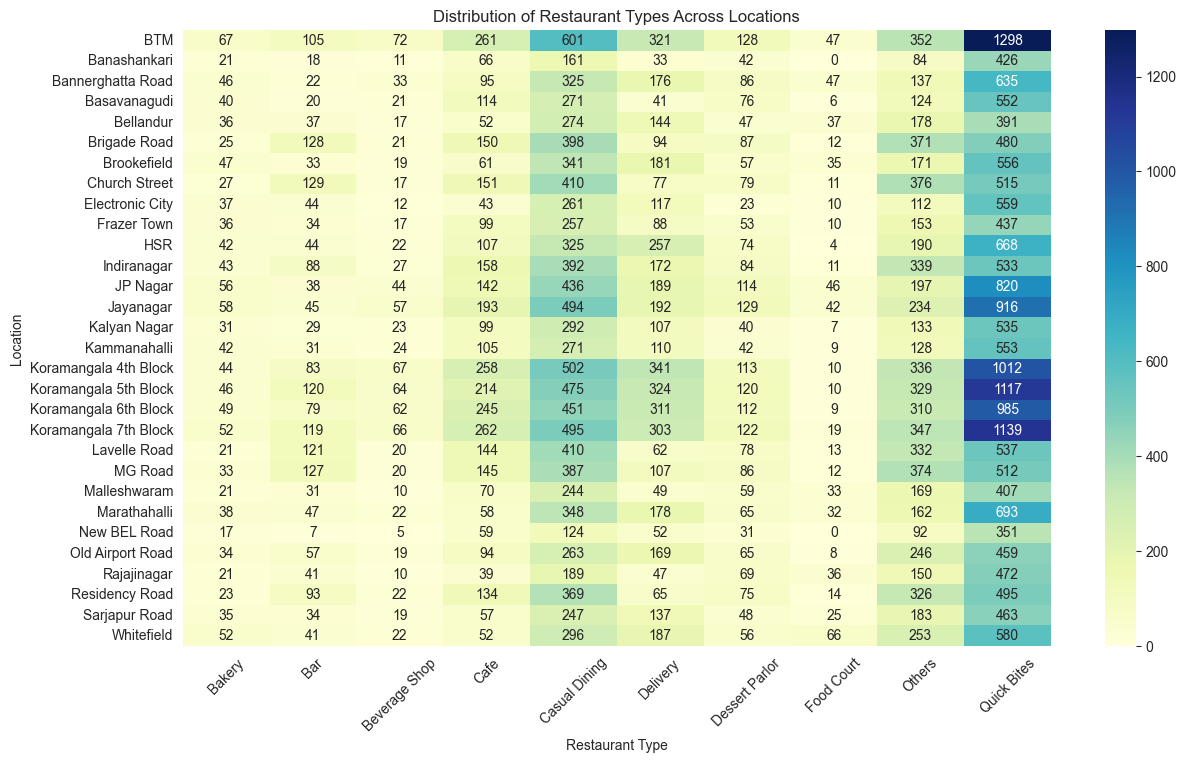

In [226]:
# Create Cross-tabulation
location_rest_type_crosstab = pd.crosstab(df['location'], df['rest_type'])
print(location_rest_type_crosstab)

# Visualization
plt.figure(figsize=(14, 8))
sns.heatmap(location_rest_type_crosstab, annot=True, fmt='d', cmap='YlGnBu', cbar=True)
plt.title('Distribution of Restaurant Types Across Locations')
plt.xlabel('Restaurant Type')
plt.ylabel('Location')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


        rest_type      rate       votes
1             Bar  3.939675  811.843360
8          Others  3.880894  711.695557
6  Dessert Parlor  3.844248  142.735398
3            Cafe  3.834237  389.483499
4   Casual Dining  3.737307  440.335144
2   Beverage Shop  3.645202   34.832370
0          Bakery  3.643158   31.214035
5        Delivery  3.600713   67.771540
9     Quick Bites  3.587950   77.298597
7      Food Court  3.517874   57.436393


C:\Users\cikar\AppData\Local\Temp\ipykernel_14096\2801026309.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=average_ratings, x='rate', y='rest_type', palette='viridis')


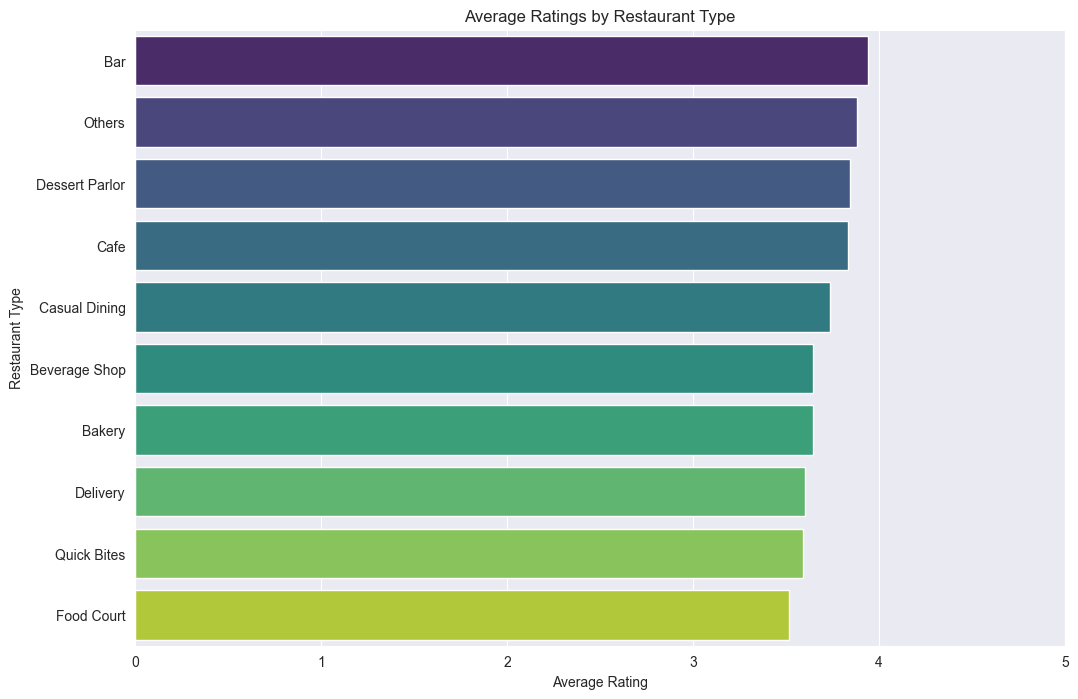

In [227]:
# Calculate Average Ratings for Each Restaurant Type
average_ratings = df.groupby('rest_type')[['rate', 'votes']].mean().reset_index()

# Sort the DataFrame by average rating
average_ratings.sort_values('rate', ascending=False, inplace=True)

# Display the average ratings DataFrame
print(average_ratings)

# Step 4: Visualization
plt.figure(figsize=(12, 8))
sns.barplot(data=average_ratings, x='rate', y='rest_type', palette='viridis')
plt.title('Average Ratings by Restaurant Type')
plt.xlabel('Average Rating')
plt.ylabel('Restaurant Type')
plt.xlim(0, 5)
plt.show()

C:\Users\cikar\AppData\Local\Temp\ipykernel_14096\2557404873.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['is_chain'] = df['name'].duplicated(keep=False)
C:\Users\cikar\AppData\Local\Temp\ipykernel_14096\2557404873.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=chain_analysis, x='is_chain', y='votes', palette='muted')


   is_chain      rate       votes
0     False  3.605478   46.867224
1      True  3.703501  289.324361


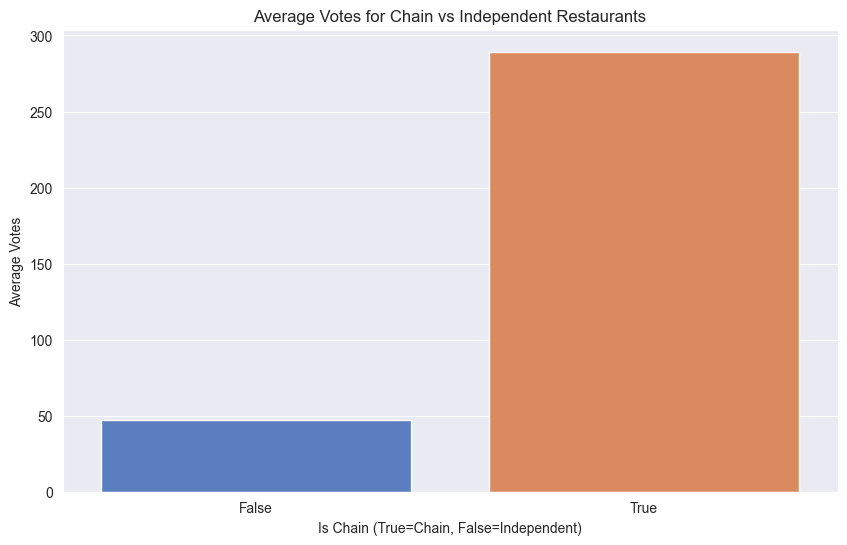

C:\Users\cikar\AppData\Local\Temp\ipykernel_14096\2557404873.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=chain_analysis, x='is_chain', y='rate', palette='muted')


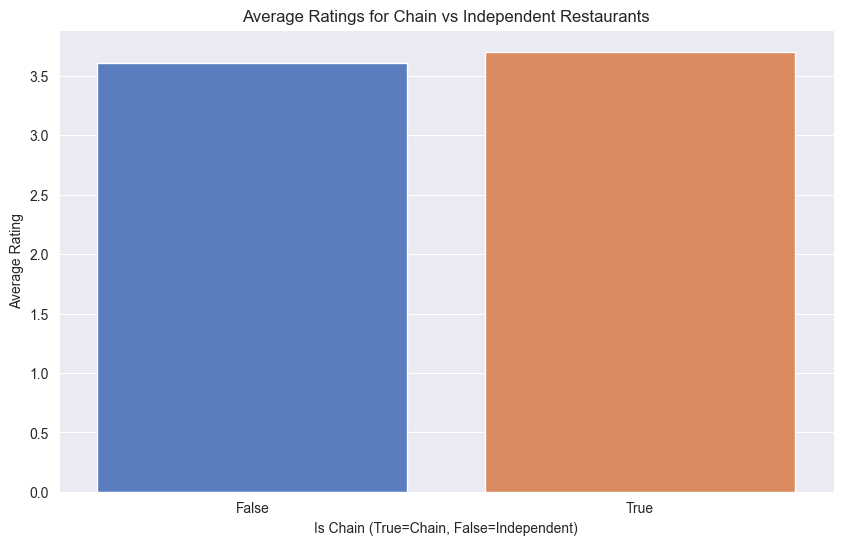

In [228]:
# Create the 'is_chain' column
# A restaurant is considered a chain if its name appears more than once
df['is_chain'] = df['name'].duplicated(keep=False)

# Step 3: Group by 'is_chain' to calculate average ratings and votes
chain_analysis = df.groupby('is_chain')[['rate', 'votes']].mean().reset_index()
print(chain_analysis)

plt.figure(figsize=(10, 6))
sns.barplot(data=chain_analysis, x='is_chain', y='votes', palette='muted')
plt.title('Average Votes for Chain vs Independent Restaurants')
plt.xlabel('Is Chain (True=Chain, False=Independent)')
plt.ylabel('Average Votes')
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=chain_analysis, x='is_chain', y='rate', palette='muted')
plt.title('Average Ratings for Chain vs Independent Restaurants')
plt.xlabel('Is Chain (True=Chain, False=Independent)')
plt.ylabel('Average Rating')
plt.show()


c:\users\cikar\appdata\local\programs\python\python39\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


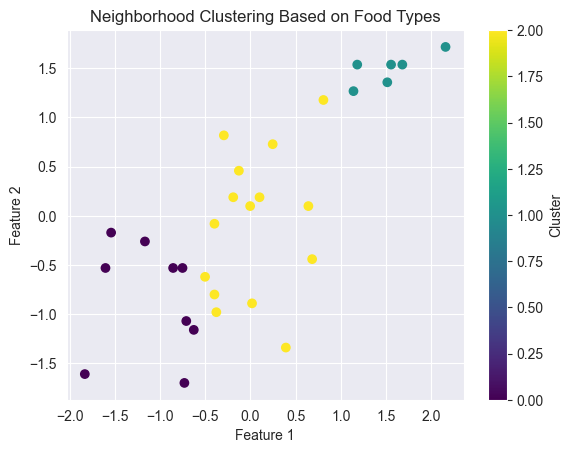

   cluster                                                     \
0        0  Banashankari, Electronic City, Frazer Town, Ka...   
1        1  BTM, Jayanagar, Koramangala 4th Block, Koraman...   
2        2  Bannerghatta Road, Basavanagudi, Bellandur, Br...   

                                                   D  \
0  Banashankari, Electronic City, Frazer Town, Ka...   
1  BTM, Jayanagar, Koramangala 4th Block, Koraman...   
2  Bannerghatta Road, Basavanagudi, Bellandur, Br...   

                                                   I  \
0  Banashankari, Electronic City, Frazer Town, Ka...   
1  BTM, Jayanagar, Koramangala 4th Block, Koraman...   
2  Bannerghatta Road, Basavanagudi, Bellandur, Br...   

                                                   M  \
0  Banashankari, Electronic City, Frazer Town, Ka...   
1  BTM, Jayanagar, Koramangala 4th Block, Koraman...   
2  Bannerghatta Road, Basavanagudi, Bellandur, Br...   

                                                   N  \
0  Banas

In [230]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Step 1: Explode the 'cuisines' column
df_exploded = df.explode('cuisines')

# Step 2: One-Hot Encode the Cuisines
mlb = MultiLabelBinarizer()
cuisines_encoded = mlb.fit_transform(df_exploded['cuisines'])
cuisines_df = pd.DataFrame(cuisines_encoded, columns=mlb.classes_)

# Step 3: Combine with original DataFrame
features = pd.concat([df_exploded[['location']], cuisines_df], axis=1)

# Step 4: Group by location and sum the one-hot encoded cuisines
features_grouped = features.groupby('location').sum()

# Step 5: Standardize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_grouped)

# Step 6: Apply K-Means Clustering
kmeans = KMeans(n_clusters=3)  # Adjust the number of clusters
features_grouped['cluster'] = kmeans.fit_predict(features_scaled)

# Step 7: Analyze Clusters
cluster_analysis = features_grouped.groupby('cluster').agg(lambda x: ', '.join(x.index[x > 0])).reset_index()

# Step 8: Visualization (Optional)
plt.scatter(features_scaled[:, 0], features_scaled[:, 1], c=features_grouped['cluster'], cmap='viridis')
plt.title('Neighborhood Clustering Based on Food Types')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster')
plt.show()

# Print cluster analysis
print(cluster_analysis)


In [238]:
# Explode the 'cuisines' column
df_exploded = df.explode('cuisines')

# Count occurrences of each cuisine by neighborhood
cuisine_counts = df_exploded.groupby(['location', 'cuisines']).size().reset_index(name='count')

# Find the most popular cuisine in each neighborhood
popular_cuisines = cuisine_counts.loc[cuisine_counts.groupby('location')['count'].idxmax()]

# Create a DataFrame of maximum counts for each location
max_counts = cuisine_counts.groupby('location')['count'].max().reset_index()
max_counts.columns = ['location', 'max_count']  # Rename for clarity

# Merge to get max_count with popular_cuisines
famous_cuisines = popular_cuisines.merge(max_counts, on='location')

# Define a threshold for "famous" cuisine (it appears at least twice as much as the second most popular)
threshold = 2  # Adjust this threshold based on your preference

# Find neighborhoods where the most popular cuisine meets the threshold
famous_cuisines['is_famous'] = famous_cuisines['count'] > (famous_cuisines['max_count'] / threshold)

# Filter for neighborhoods with a famous cuisine
famous_neighborhoods = famous_cuisines[famous_cuisines['is_famous']]
print(famous_neighborhoods[['location', 'cuisines', 'count']])


                 location cuisines  count
0                     BTM   Others   2608
1            Banashankari   Others    622
2       Bannerghatta Road   Others   1270
3            Basavanagudi   Others    946
4               Bellandur   Others    888
5            Brigade Road   Others   1444
6             Brookefield   Others   1120
7           Church Street   Others   1463
8         Electronic City   Others    941
9             Frazer Town   Others    938
10                    HSR   Others   1345
11            Indiranagar   Others   1458
12               JP Nagar   Others   1640
13              Jayanagar   Others   1870
14           Kalyan Nagar   Others   1057
15           Kammanahalli   Others   1065
16  Koramangala 4th Block   Others   2198
17  Koramangala 5th Block   Others   2230
18  Koramangala 6th Block   Others   2073
19  Koramangala 7th Block   Others   2302
20           Lavelle Road   Others   1395
21                MG Road   Others   1471
22           Malleshwaram   Others

In [242]:
df['location'].unique()

array(['Banashankari', 'Bannerghatta Road', 'Basavanagudi', 'Bellandur',
       'Brigade Road', 'Brookefield', 'BTM', 'Church Street',
       'Electronic City', 'Frazer Town', 'HSR', 'Indiranagar',
       'Jayanagar', 'JP Nagar', 'Kalyan Nagar', 'Kammanahalli',
       'Koramangala 4th Block', 'Koramangala 5th Block',
       'Koramangala 6th Block', 'Koramangala 7th Block', 'Lavelle Road',
       'Malleshwaram', 'Marathahalli', 'MG Road', 'New BEL Road',
       'Old Airport Road', 'Rajajinagar', 'Residency Road',
       'Sarjapur Road', 'Whitefield'], dtype=object)

In [229]:
# nomor 7
neighborhood_similarity = df.pivot_table(index='location', columns='rest_type', values='rate', aggfunc='mean').fillna(0)
neighborhood_similarity

rest_type,Bakery,Bar,Beverage Shop,Cafe,Casual Dining,Delivery,Dessert Parlor,Food Court,Others,Quick Bites
location,,,,,,,,,,
BTM,3.677612,4.064762,3.615278,3.868582,3.755408,3.575078,3.921875,3.531915,3.879545,3.601387
Banashankari,3.714286,3.400000,3.836364,3.748485,3.736646,3.660606,3.697619,0.000000,3.695238,3.634507
Bannerghatta Road,3.654348,4.031818,3.593939,3.672632,3.589846,3.617045,3.677907,3.487234,3.648905,3.543465
Basavanagudi,3.695000,3.555000,3.833333,3.857018,3.759410,3.658537,3.831579,3.683333,3.724194,3.632790
Bellandur,3.600000,4.170270,3.623529,3.751923,3.581387,3.643056,3.831915,3.451351,3.847191,3.524552
Brigade Road,3.552000,3.971875,3.661905,3.831333,3.803266,3.626596,3.893103,3.600000,3.978437,3.588125
Brookefield,3.619149,3.709091,3.600000,3.598361,3.595894,3.572376,3.717544,3.485714,3.738012,3.553777
Church Street,3.551852,3.985271,3.652941,3.853642,3.799512,3.609091,3.868354,3.609091,3.992553,3.589126
Electronic City,3.500000,3.559091,3.708333,3.483721,3.510345,3.585470,3.543478,3.630000,3.746429,3.552594


In [254]:
df.groupby('location')['dish_liked'].apply(lambda x: x.mode())

location            
BTM                0                                              Biryani
Banashankari       0    Pasta, Gelato, Garlic Bread, Mojito, Nachos, P...
Banaswadi          0                                       Mutton Biryani
Bannerghatta Road  0        Coffee, French Fries, Lemon Tea, Veg Sandwich
Basavanagudi       0                                          Masala Dosa
                                              ...                        
Yeshwantpur        5                             Chicken Sukha, Neer Dosa
                   6                                Jeera Rice, Idli Vada
                   7    Pork Pepper Fry, Mutton Chops, Mutton Biryani,...
                   8    Salads, Chicken Soup, Fish, Curd Rice, Dal Tad...
                   9    Vada Pav, Dabeli, Pav Bhaji, Chaat, Misal Pav,...
Name: dish_liked, Length: 190, dtype: object

In [256]:
liked_dishes_counts = df.groupby(['location', 'dish_liked']).size().reset_index(name='count')

top_n = 3
top_liked_dishes = liked_dishes_counts.sort_values(['location', 'count'], ascending=[True, False])
top_liked_dishes = top_liked_dishes.groupby('location').head(top_n)

# Output the results
print(top_liked_dishes)


           location                                         dish_liked  count
10              BTM                                            Biryani     24
125             BTM                                        Masala Dosa     21
157             BTM  Paneer Tikki, Mutton Raan, Mango Margarita, Cr...     17
302    Banashankari  Pasta, Gelato, Garlic Bread, Mojito, Nachos, P...     13
254    Banashankari  Churros, Cannelloni, Minestrone Soup, Hot Choc...     10
...             ...                                                ...    ...
5536  Wilson Garden                                               Beer      5
5542      Yelahanka            Appam, Fish Curry, Fish Fry, Pothichoru      2
5544    Yeshwantpur  Badam Milk, Chaat, Sandwich, Noodles, Ghee Dos...      2
5545    Yeshwantpur                             Bamboo Chicken Biryani      2
5546    Yeshwantpur  Beef Biryani, Paratha, Fish Curry, Chicken Bir...      2

[247 rows x 3 columns]


In [257]:
df['cuisines'].unique()

array(['North Indian, Mughlai, Chinese', 'Chinese, North Indian, Thai',
       'Cafe, Mexican, Italian', ...,
       'North Indian, Street Food, Biryani', 'Chinese, Mughlai',
       'North Indian, Chinese, Arabian, Momos'], dtype=object)

In [258]:
df['dish_liked'].unique()

array(['Pasta, Lunch Buffet, Masala Papad, Paneer Lajawab, Tomato Shorba, Dum Biryani, Sweet Corn Soup',
       'Momos, Lunch Buffet, Chocolate Nirvana, Thai Green Curry, Paneer Tikka, Dum Biryani, Chicken Biryani',
       'Churros, Cannelloni, Minestrone Soup, Hot Chocolate, Pink Sauce Pasta, Salsa, Veg Supreme Pizza',
       ...,
       'Noodles, Chicken Noodle, Momos, American Chopsuey, Salad, Manchow Soup, Manchurian',
       'Chicken Quesadilla, Naan, Breakfast Buffet, Cheesecake, Cocktails, Lunch Buffet, Biryani',
       'Biryani, Andhra Meal'], dtype=object)

In [259]:
df['location'].unique()

array(['Banashankari', 'Basavanagudi', 'Mysore Road', 'Jayanagar',
       'Kumaraswamy Layout', 'Rajarajeshwari Nagar', 'Vijay Nagar',
       'Uttarahalli', 'JP Nagar', 'South Bangalore', 'City Market',
       'Nagarbhavi', 'Bannerghatta Road', 'BTM', 'Kanakapura Road',
       'Bommanahalli', nan, 'CV Raman Nagar', 'Electronic City', 'HSR',
       'Marathahalli', 'Sarjapur Road', 'Wilson Garden', 'Shanti Nagar',
       'Koramangala 5th Block', 'Koramangala 8th Block', 'Richmond Road',
       'Koramangala 7th Block', 'Jalahalli', 'Koramangala 4th Block',
       'Bellandur', 'Whitefield', 'East Bangalore', 'Old Airport Road',
       'Indiranagar', 'Koramangala 1st Block', 'Frazer Town', 'RT Nagar',
       'MG Road', 'Brigade Road', 'Lavelle Road', 'Church Street',
       'Ulsoor', 'Residency Road', 'Shivajinagar', 'Infantry Road',
       'St. Marks Road', 'Cunningham Road', 'Race Course Road',
       'Commercial Street', 'Vasanth Nagar', 'HBR Layout', 'Domlur',
       'Ejipura', 'Jeevan 

In [263]:
df['dish_liked'].value_counts()

dish_liked
Biryani                                                                                              182
Chicken Biryani                                                                                       73
Friendly Staff                                                                                        69
Waffles                                                                                               68
Paratha                                                                                               57
                                                                                                    ... 
Butter Chicken, Shawarma Roll, Chicken Shawarama, Chicken Grill, Rolls, Al Faham Chicken, Biryani      1
Filter Coffee, Sandwich, Bonda, Vada, Masala Dosa, Salad, Aloo Curry                                   1
Burgers, Fries, Jumbo Royale Burger, Salads, Peri Peri Chicken Salad, Potato Wedges, Rolls             1
Chaat, Pav Bhaji, Raj Kachori, Buttermilk, A